(ch:linear-correlation)=
# 선형 상관관계

데이터 분석에서 가장 빈번하게 마주치는 질문 중 하나는 "두 종류의 데이터가 서로 얼마나 밀접하게 연관되어 있는가?"이다.
이때 한 데이터의 값이 커짐에 따라 다른 데이터의 값도 일정한 비율로 증가(양의 상관관계)하거나 감소(음의 상관관계)하는 직선 형태의 경향성을 선형 상관관계<font size='2'>linear correlation</font>라고 부른다.

2차원 데이터를 다루는 대부분의 경우 이러한 선형 상관관계 여부를 최우선으로 분석하며, 해당 연관성의 유무와 강도를 객관적으로 측정하기 위한 척도로서 공분산<font size='2'>covariance</font>과 상관계수<font size='2'>correlation coefficient</font>를 주로 사용한다.

**기본 설정**

EDA에 필요한 핵심 라이브러리를 불러온다.

- `numpy`: 수치 연산
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 데이터 시각화

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

데이터프레임 내 부동소수점을 소수점 이하 6자리까지만 출력하도록 지정한다.

In [23]:
pd.set_option('display.precision', 6)

**데이터 저장소**

In [24]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

## 상관관계 종류

두 데이터 사이의 선형 상관관계는 크게 세 가지로 나눌 수 있다.

1. **양의 상관관계**: 한 데이터의 값이 증가할 때 다른 데이터의 값도 증가하는 경향. (예: 운동 시간과 근육량)
2. **음의 상관관계**: 한 데이터의 값이 증가할 때 다른 데이터의 값은 감소하는 경향. (예: 자동차 무게와 연비)
3. **무상관 (상관관계 없음)**: 산점도가 뚜렷한 패턴 없이 퍼져 있어 직선 형태의 관계를 찾기 힘든 경우.

설명을 위해 1,000 명의 신체 정보를 담은 `body_fat.csv` 파일을 활용한다.

`body_df.csv` 파일은 성인 남녀 1,000명(여성 500명, 남성 500명)의 신체 정보를 담고 있으며, 6개의 데이터로 구성된다.

| 데이터 | 설명 | 타입 |
|------|------|------|
| `ID` | 샘플 고유 식별자 (F001~F500: 여성, M001~M500: 남성) | 문자열 |
| `Sex` | 성별 (F: 여성, M: 남성) | 범주형 |
| `Age` | 나이 (세) | 수치형 |
| `Height` | 키 (cm) | 수치형 |
| `Weight` | 몸무게 (kg) | 수치형 |
| `Body fat percentage` | 체지방률 (%) | 수치형 |

**데이터셋 불러오기**

`ID` 특성을 행 인덱스로 지정하면서 데이터셋을 데이터프레임으로 불러온다.

In [25]:
body_df = pd.read_csv(data_url + "body_fat.csv", index_col='ID')
body_df

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
F001,F,37.0,161.4,62.9,32.8
F002,F,26.0,168.1,56.1,31.5
F003,F,39.0,163.4,53.2,25.2
F004,F,30.0,164.1,49.4,21.8
F005,F,44.0,152.9,51.9,24.2
...,...,...,...,...,...
M496,M,48.0,176.4,95.5,29.7
M497,M,75.0,157.4,63.9,34.9
M498,M,58.0,167.3,68.0,15.6


`info()` 메서드로 각 열의 데이터 타입과 결측치 여부를 확인한다.
`Sex` 특성만 문자열로 구성되었다. 즉 범주형 특성이다.
나머지 특성은 모두 부동소수점 자료형을 갖는다. 즉 수치형 특성이다.

In [26]:
body_df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, F001 to M500
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sex                  1000 non-null   str    
 1   Age                  1000 non-null   float64
 2   Height               1000 non-null   float64
 3   Weight               1000 non-null   float64
 4   Body fat percentage  1000 non-null   float64
dtypes: float64(4), str(1)
memory usage: 51.8 KB


`Body fat percentage`와 같이 띄어쓰기가 포함된 긴 열의 이름을 간결한 이름인 `BFP`로 변경한다. 열의 이름이 수정된 새로운 데이터프레임을 기존 변수에 재할당하는 방식으로 사용한다.

In [27]:
body_df = body_df.rename(columns={'Body fat percentage': 'BFP'})
body_df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, F001 to M500
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sex     1000 non-null   str    
 1   Age     1000 non-null   float64
 2   Height  1000 non-null   float64
 3   Weight  1000 non-null   float64
 4   BFP     1000 non-null   float64
dtypes: float64(4), str(1)
memory usage: 51.8 KB


## 상관관계와 산점도

`body_df` 데이터프레임에 특성으로 포함된 데이터들 사이의 상관관계를 
산점도<font size='2'>scatter plot</font>를 이용하여 확인해 본다.
양(+), 음(-), 그리고 무관한 상관관계를 보여주는 특성들이 모두 보여진다.

**양의 상관관계: 키(`Height`) vs 몸무게(`Weight`)**

<Axes: xlabel='Height', ylabel='Weight'>

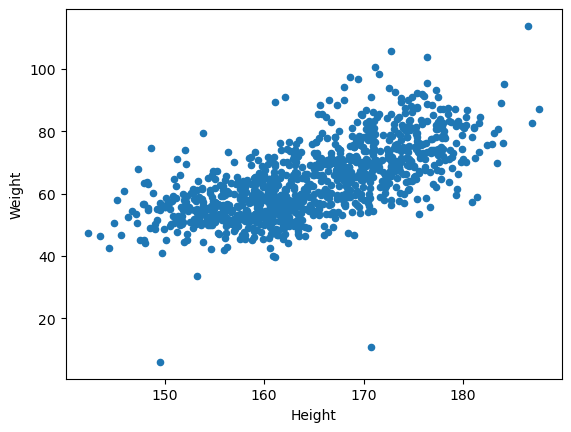

In [28]:
body_df.plot.scatter(x='Height', y='Weight')

**음의 상관관계: 키(`Height`) vs 체지방률(`BFP`)**

<Axes: xlabel='Height', ylabel='BFP'>

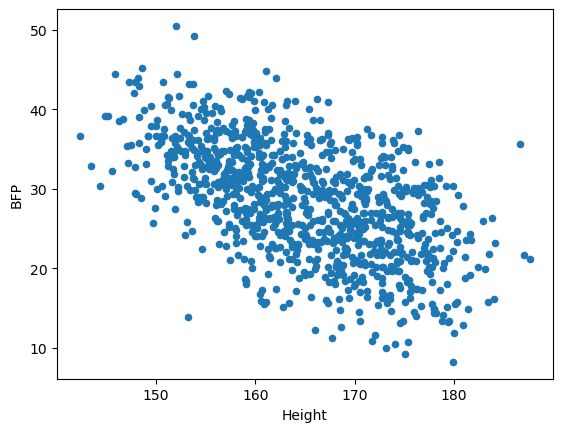

In [29]:
body_df.plot.scatter(x='Height', y='BFP')

**무관한 상관관계: 나이(`Age`) vs 몸무게(`Weight`)**

<Axes: xlabel='Age', ylabel='Weight'>

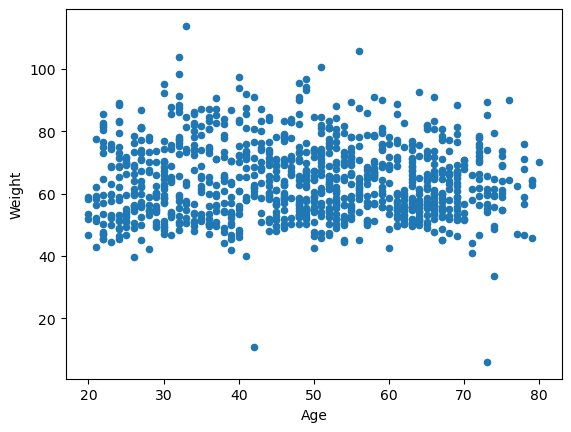

In [30]:
body_df.plot.scatter(x='Age', y='Weight')

선형 상관관계를 
**공분산**<font size='2'>covariance</font>과 
**상관계수**<font size='2'>correlation coefficient</font> 두 개의 척도를 통해 수치화할 수 있다.
먼저 공분산을 소개한다.

## 상관관계 vs 인과관계 

데이터 분석 시 산점도를 무시하고 통계치(상관계수) 절댓값 하나만 맹신하거나 관계의 본질을 오해하는 경우가 빈번하다. 여기서는 입문자가 흔히 범하는 대표적인 함정 두 가지를 살펴본다.

> **상관관계 $\neq$ 인과관계 (Correlation does not imply causation)**

상관관계가 높다고 해서 반드시 두 변수 사이의 선행(원인)/후행(결과) **인과성**이 보장되는 것은 아니다. 제3의 변수(교란 변수)가 두 변수 모두에 영향을 미치는 **허위 상관관계(Spurious Correlation)**일 수 있다. 다음과 같은 고전적이고 확실한 실무·논문 사례들이 있다.

* **사례 1. 황새 무리 수와 신생아 출생률 (Storks and Babies)**:
  * 통계학자인 로버트 매슈스(Robert Matthews)가 연구하여 발표한 실제 데이터 기반 사례다. 17개 유럽 국가 통계를 확인한 결과 국가별 '황새 둥지 수'와 '신생아 출생 수' 사이에 매우 강한 양(+)의 상관관계가 나타났다.
  * **진범(제3의 변수): 국가의 영토 크기와 인구수**. 영토가 큰 국가일수록 자연환경이 넓어 황새가 많이 서식하며, 동시에 모수가 되는 인구수 자체도 많아 신생아 수도 많은 것이다. 즉, 황새가 아기를 물어다 주는 것(인과관계)이 아니다.
  
* **사례 2. 소방관 수와 화재 피해액**:
  * 특정 도시의 화재 기록을 모아 분석한 결과, 현장에 출동한 '소방관의 수'와 '재산 피해액' 사이에 매우 강한 양의 상관관계가 관찰되었다. 그렇다면 소방관이 많이 투입될수록 오히려 피해를 키우는 원인이 된 것일까?
  * **진범(제3의 변수): 화재의 규모**. 화재 규모가 컸기 때문에 재산 피해가 막대했던 것이고, 동시에 진압을 위해 더 많은 소방관이 호출되었을 뿐이다.

* **사례 3. 발 크기와 어휘력 수준 (Shoe Size vs. Vocabulary)**:
  * 통계 입문서에서 자주 쓰이는 사례로 초등학생을 대상으로 조사한 결과, '발 크기'가 큰 학생일수록 시험에서 '독해력(어휘력)' 점수가 높게 측정되었다.
  * **진범(제3의 변수): 학생의 나이(학년)**. 학년이 올라갈수록 신체가 성장해 발이 커지며, 동시에 학습 기간이 늘어나 독해력이 상승한 것이다.

## 공분산

이전 장에서
다룬 분산<font size='2'>variance</font>은 한 종류의 데이터 
$X=\{ x_1,\cdots, x_n \}$에 대해 샘플값들의 편차의 제곱의 평균값이다.
아래 식과 같이 계산되며, 샘플값들이 평균으로부터 떨어져있는 정도를 나타내는 양의 측정치이다.

$$
S_X^2 = \frac 1 n \sum_{i=1}^{n} (x_i - \bar x)^2 = \frac 1 n \left\{(x_1 - \bar x)^2 + (x_2 - \bar x)^2 + \cdots + (x_n - \bar x)^2 \right \}
$$


공분산<font size='2'>covariance</font>은 두 종류의 데이터 $X=\{ x_1, \cdots, x_n \}$와 $Y=\{ y_1,
\cdots, y_n \}$에 대해 다음과 같이 정의하며 $S_{XY}$로 표기하자.

$$
\begin{align*}
S_{XY} & = \frac 1 n \sum_{i=1}^{n} (x_i - \bar x)(y_i - \bar y) \\
&= \frac 1 n \left\{ (x_1 - \bar x)(y_1 - \bar y) + (x_2 - \bar x)(y_2 - \bar y) + \cdots + (x_n - \bar x)(y_n - \bar y) \right\}
\end{align*}
$$

위의 두 식으로부터 알 수 있는 사실은, 분산과 달리 공분산은 음수가 나올 수 있다는 것이다.
분산은 한 종류의 데이터에 대해 편차의 제곱의 평균이므로 항상 양의 값을 갖는다. 하지만 공분산은 두 종류의 데이터에 대해 편차의 곱의 평균인데, 곱해지는 편차의 부호가 다른 항들은 음수가 되므로 평균 또한 음수가 될 수 있다.

데이터프레임 객체의 `cov()` 메서드는 모든 특성들 사이의 공분산을 계산한다.
선형 상관관계는 수치형 데이터에 대해서만 작동한다.
또한 `ddof=0`을 지정해야 편향 분산 방식으로 공분산을 계산한다.

In [31]:
body_df.cov(ddof=0, numeric_only=True)

,Age,Height,Weight,BFP
Age,232.177671,-47.943871,-7.074432,36.136552
Height,-47.943871,73.004293,67.435018,-34.197707
Weight,-7.074432,67.435018,143.471750,-0.116165
BFP,36.136552,-34.197707,-0.116165,49.334098


공분산을 계산하고자 하는 특성들을 먼저 지정해도 된다.
예를 들어, 아래 코드는 키와 체지방률 사이의 공분산을 계산한다.

In [32]:
body_df[['Height', 'BFP']].cov(ddof=0)

,Height,BFP
Height,73.004293,-34.197707
BFP,-34.197707,49.334098


**참고**

`ddof=1`로 지정하면 불편분산이 계산된다.
즉, $S_{XY}$를 계산하는 식에서 $n$이 아닌 $(n-1)$로 나눈다.

In [33]:
body_df[['Height', 'BFP']].cov(ddof=1)

,Height,BFP
Height,73.077370,-34.231939
BFP,-34.231939,49.383481


**공분산의 한계**

공분산의 최대 약점은 관측 데이터의 단위에 값이 크게 영향을 받는다는 점입니다.
예를 들어 키를 인치로 단위를 변환하면 실제 두 변수 간의 관계는 똑같음에도 불구하고 공분산 값은 2.54배 줄어든다. 
이로 인해 공분산 값만으로는 "상관관계가 얼마나 강한지"를 절대적으로 평가하기가 불가능하다.

In [34]:
body_df_scaled = body_df.copy()
# 키를 cm에서 inch로 변환 (1 inch = 2.54 cm)
body_df_scaled['Height_scaled'] = body_df_scaled['Height'] / 2.54

body_df_scaled['Height_scaled'].cov(body_df_scaled['BFP'])

np.float64(-13.477141484003697)

## 상관계수

앞서 설명한 것처럼 공분산은 데이터의 크기와 단위와 척도(scale)에 따라 계산된 값의 크기와 단위가 달라진다.
이 점을 보완한 척도가 **상관계수**<font size='2'>correlation coefficient</font>이다. 
상관계수를 계산하는 다양한 방버이 알려져 있으나, **피어슨 상관계수**<font size='2'>Pearson correlation coefficient</font>가 가장 많이 활용된다.

데이터 $X$와 $Y$의 피어슨 상관계수 $r_{XY}$는 공분산 $S_{XY}$를 각 데이터의 표준편차 $S_X$와 $S_Y$로 나눈 값이다. 
아래 계산식으로부터 알 수 있듯이, 두 데이터의 단위 및 척도와 무관하게 항상 -1과 1 사이의 값으로
계산된다.

$$
r_{xy} = \frac{S_{xy}}{S_x \cdot S_y}
$$

피어슨 상관계수의 값으로부터 두 데이터의 상관관계는 다음과 같이 평가된다.

| 상관계수 | 의미 |
| :--- | :--- |
| 1에 가까운 값 | 양의 상관관계가 강함 |
| -1에 가까운 값 | 음의 상관관계가 강함 |
| 0에 가까운 값 | 상관관계가 거의 없음 |

아래 그림은 다양한 상관계수에 대응되는 산점도들이다.
상관계수의 절댓값이 1에 가까워질수록 산점도가 직선에 가까워지며,
0에 가까워질수록 산점도가 여러 방향으로 넓게 퍼져 두 데이터의 상관관계가 모호해진다.

<p><div align="center"><img src="https://github.com/codingalzi/statsRev/blob/master/jupyter-book/images/pearson_correlation.png?raw=true" style="width:700px"></div></p>

<p><div style="text-align: center">&lt;그림 출처: <a href="https://en.wikipedia.org/wiki/Pearson_correlation_coefficient">(Wikipedia) 피어슨 상관계수</a>&gt;</div></p>

`body_df` 데이터프레임에 포함된 모든 특성들 사이의 상관관계를 
한꺼번에 산점도<font size='2'>scatter plot</font>를 이용하여 확인하면
양(+), 음(-), 그리고 무관한 상관관계를 보여주는 특성들이 모두 보여진다.

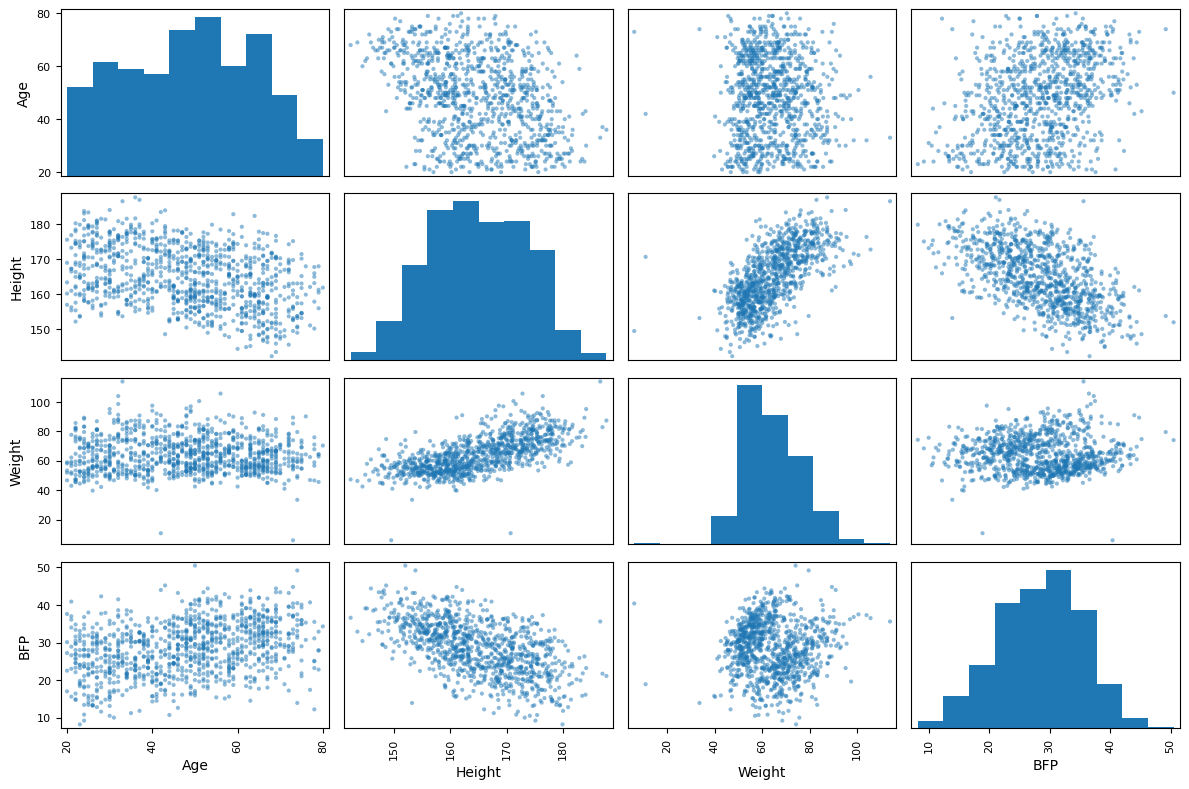

In [35]:
from pandas.plotting import scatter_matrix

# 산점도 행렬 생성
axs = scatter_matrix(body_df.iloc[:, 1:], figsize=(12, 8))

# 플롯 간격 조정
plt.tight_layout()
plt.show()

**데이터프레임의 `corr()` 메서드**

데이터프레임의 `corr()` 메서드는 수치형 특성들 사이의 피어슨 상관계수를 일괄 계산한다.

In [36]:
body_df.corr(numeric_only=True)

,Age,Height,Weight,BFP
Age,1.000000,-0.368255,-0.038761,0.337647
Height,-0.368255,1.000000,0.658913,-0.569835
Weight,-0.038761,0.658913,1.000000,-0.001381
BFP,0.337647,-0.569835,-0.001381,1.000000


피어슨 상관계수는 단위 또는 척도가 변경되더라도 달라지지 않는다.
아래 코드는 키 특성에 대해 표준화를 진행한다.

In [41]:
height_col = body_df[['Height']]
height_z = (height_col - height_col.mean()) / height_col.std(ddof=0)

body_df_copy = body_df.copy()
body_df_copy['Height_z'] = height_z
body_df_copy.head()

,Sex,Age,Height,Weight,BFP,Height_z
ID,,,,,,
F001,F,37.0,161.4,62.9,32.8,-0.399298
F002,F,26.0,168.1,56.1,31.5,0.384855
F003,F,39.0,163.4,53.2,25.2,-0.165222
F004,F,30.0,164.1,49.4,21.8,-0.083296
F005,F,44.0,152.9,51.9,24.2,-1.394118


표준화를 통해 키 특성값의 척도를 다르게 하더라도 다른 특성들과의 상관계수가 달라지지 않는다.

In [40]:
body_df_copy.corr(numeric_only=True).loc[['Height', 'Height_z']]

,Age,Height,Weight,BFP,Height_z
Height,-0.368255,1.0,0.658913,-0.569835,1.0
Height_z,-0.368255,1.0,0.658913,-0.569835,1.0


### 상관관계 히트맵 (Heatmap) 예시

전체의 열람을 위해 Pandas 객체의 여러 특성들 사이의 피어슨 `corr()` 수치를 표 형태의 테이블로 나열하기보단, 행렬의 상관계수 강도(`-1` ~ `+1`)에 색상을 입혀 직관적인 데이터 분석 도면으로 볼 때 주로 `seaborn` 라이브러리의 `sns.heatmap()`을 쓴다.

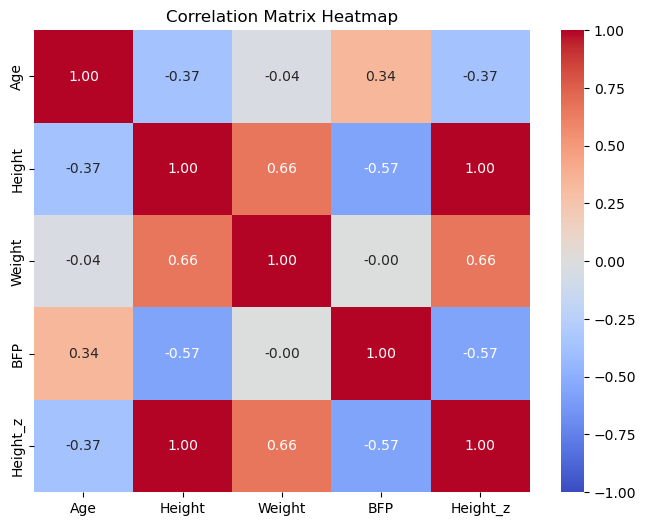

In [ ]:
import seaborn as sns

corr_matrix = body_df_copy.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

상관관계가 대각선을 기준으로 대칭이기에 아랫쪽 삼각형 영역만 보여주기도 한다.

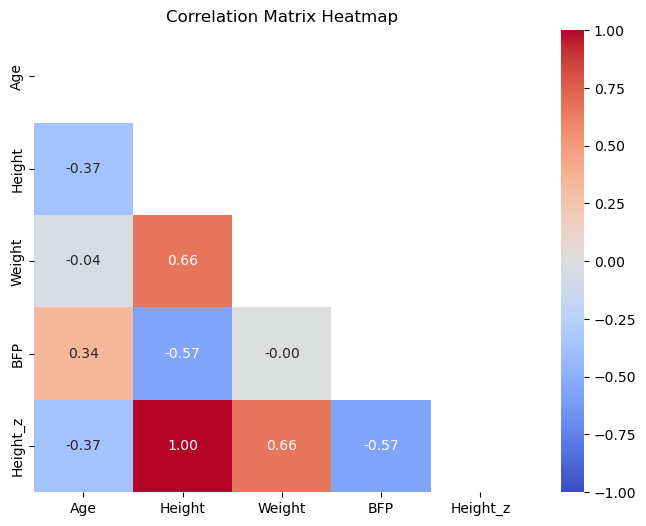

In [ ]:
import seaborn as sns

corr_matrix = body_df_copy.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # 대각선과 그 위쪽 삼각형 영역을 마스킹
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, mask=mask)
plt.title('Correlation Matrix Heatmap')
plt.show()

## 앤스콤 콰르텟 (Anscombe's Quartet)

피어슨 상관계수($r$)는 특정 위치에 멀찍이 떨어진 한두 개의 **이상치**에 매우 극적으로 영향을 받을 수 있다. 따라서 데이터 분포를 요약한 대푯값(평균/분산/상관계수 등) 수치에만 완전히 기대는 것은 실무에서 큰 재앙을 야기한다.

데이터의 시각적 분포가 얼마나 중요한가를 증명한 유명한 사례인 **앤스콤 콰르텟 (Anscombe's Quartet; 1973)** 데이터를 살펴본다.

In [38]:
# 4개의 X, 4개의 Y로 이루어진 Anscombe 콰르텟 데이터
anscombe = pd.read_csv(data_url + "anscombe.csv")
anscombe.head()

,x1,x2,x3,x4,y1,y2,y3,y4
0,10,10,10,8,8.04,9.14,7.46,6.58
1,8,8,8,8,6.95,8.14,6.77,5.76
2,13,13,13,8,7.58,8.74,12.74,7.71
3,9,9,9,8,8.81,8.77,7.11,8.84
4,11,11,11,8,8.33,9.26,7.81,8.47


이 네 쌍의 `(x1, y1), (x2, y2), ... (x4, y4)` 변수들의 평균, 분산, 그리고 **상관계수**는 **모두 동일한 통계학적 수치**(`r ≈ 0.816`)를 반환한다.

그렇다면 이들 쌍의 분포와 선형 상관성 형태는 똑같이 생겼을까? 아래와 같이 직접 시각화해 본다.

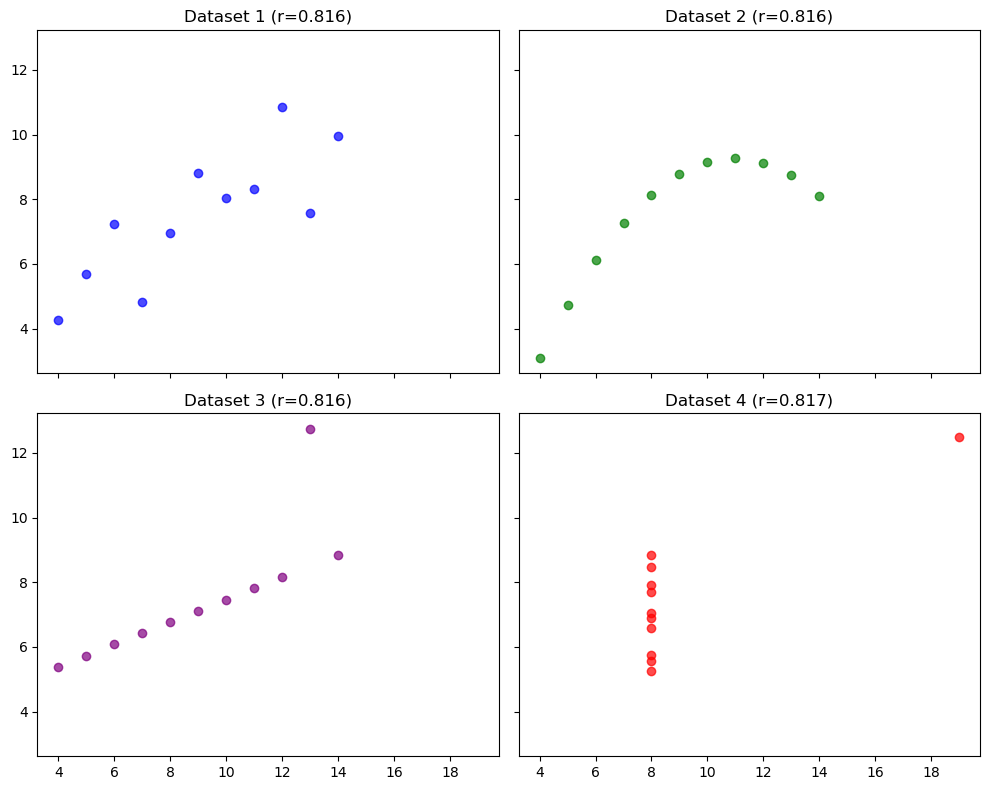

In [39]:
# 2행 2열 멀티 차트 서브플롯 준비
fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

# Dataset 1
ax[0, 0].scatter(anscombe['x1'], anscombe['y1'], color='blue', alpha=0.7)
ax[0, 0].set_title(f"Dataset 1 (r={anscombe['x1'].corr(anscombe['y1']):.3f})")

# Dataset 2
ax[0, 1].scatter(anscombe['x2'], anscombe['y2'], color='green', alpha=0.7)
ax[0, 1].set_title(f"Dataset 2 (r={anscombe['x2'].corr(anscombe['y2']):.3f})")

# Dataset 3
ax[1, 0].scatter(anscombe['x3'], anscombe['y3'], color='purple', alpha=0.7)
ax[1, 0].set_title(f"Dataset 3 (r={anscombe['x3'].corr(anscombe['y3']):.3f})")

# Dataset 4
ax[1, 1].scatter(anscombe['x4'], anscombe['y4'], color='red', alpha=0.7)
ax[1, 1].set_title(f"Dataset 4 (r={anscombe['x4'].corr(anscombe['y4']):.3f})")

plt.tight_layout()
plt.show()

놀랍게도 4개 데이터 쌍의 **피어슨 상관계수($r$)는 모두 0.816**으로 정확히 동일하며, 단순 선행 수치로만 보면 "서로 꽤 강한 양의 선형 상관관계"로 오판할 것이다. 하지만 시각화 결과는 완전히 다르다.

- **데이터 1:** 기본적인 선형 상관관계의 모습.
- **데이터 2:** 비선형 상관관계(곡선 형태)이기 때문에 단순 피어슨 선형 상관계수로 요약하는 것은 부적절하다.
- **데이터 3:** 완벽한 직선형이지만, 저 멀리 엇갈린 단 한 개의 **이상치(Outlier)**가 상관계수를 무너뜨리고 있다.
- **데이터 4:** X 변인은 통제되어 변화가 없는데(수직 방향), 하나의 악성 이상치가 피어슨 상관계수를 $r=0.816$의 완전히 왜곡된 양수로 만들었다.

**결론:** 수백 줄의 데이터를 단 하나의 통계치(상관계수) 평균 하나로 축소하는 것은 위험하다. 항상 **산점도와 다변량 분포**를 시각적으로 관찰해야 한다. 이를 위해 주로 실무에서는 Pandas `.corr()`과 시각화 라이브러리를 결합해 사용한다.

## 심슨의 역설 (Simpson's Paradox)

같은 맥락에서 **심슨의 역설**은 전체 데이터를 두고 본 상관관계와, 그룹별(제3의 변수)로 나누어 본 상관관계가 완전히 다르게(역전되어) 나타나는 현상을 말한다.

유명한 **팔머 펭귄(Palmer Penguins)** 데이터셋을 예제로 들어본다. 펭귄의 `부리 길이(bill_length_mm)`와 `부리 깊이(bill_depth_mm)` 사이의 관계를 살펴본다.

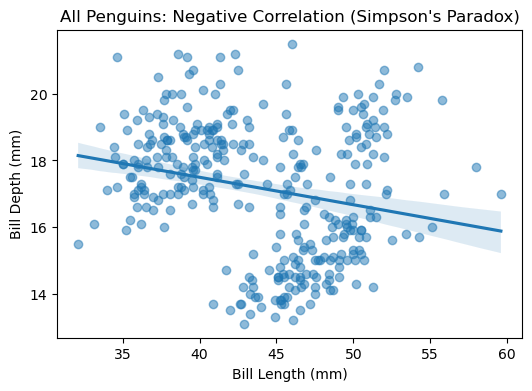

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn 라이브러리는 penguins 기본 데이터셋을 제공합니다.
penguins = sns.load_dataset("penguins").dropna()

# 전체 데이터를 대상으로 부리 길이 vs 깊이 산점도 및 선형 회귀선
plt.figure(figsize=(6, 4))
sns.regplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", scatter_kws={'alpha':0.5})
plt.title("All Penguins: Negative Correlation (Simpson's Paradox)")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show()

위 그림에서 볼 수 있듯, 모든 펭귄 데이터를 하나로 묶어놓고 보면 부리가 길어질수록 깊이는 얇아지는 명확한 **음(-)의 상관관계**를 갖는 것처럼 보인다. 그렇다면 당연하게 이 결론을 받아들이고 넘어가야 할까? 

이제 각 펭귄이 어느 **종류(Species)**인지 '보이지 않는 제3의 그룹핑 변수'를 고려하여 색상으로 구분해 다시 그려 본다.

<Figure size 800x600 with 0 Axes>

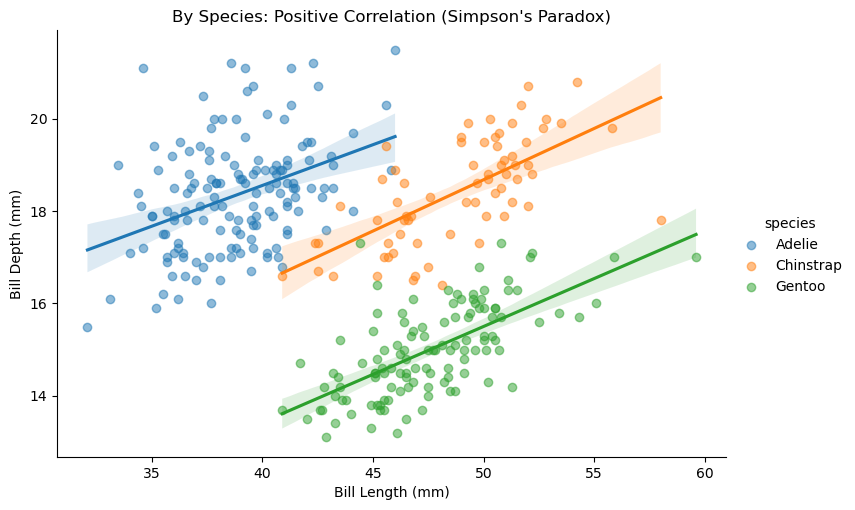

In [44]:
# '종류(species)' 열을 기준으로 3그룹으로 나누어 산점도 및 선형 회귀선 시각화
plt.figure(figsize=(8, 6))
sns.lmplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", height=5, aspect=1.5, scatter_kws={'alpha':0.5})
plt.title("By Species: Positive Correlation (Simpson's Paradox)")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show()

동일한 데이터인데도, 펭귄의 **종(Species)**이라는 그룹 효과를 제어(통제)하고 나누어서 분석하니, 각 종 별로는 부리가 길어질수록 깊이도 늘어나는 확고한 **양(+)의 상관관계**로 180도 역전된다.

이처럼 눈에 보이지 않는 중요한 특성(Confounding variable) 하나가 누락된 채 상관계수를 구하면 **전혀 정반대의 결론(음수 $\leftrightarrow$ 양수)**에 도달할 수 있는 무서운 현상을 통계학에서 `심슨의 역설`이라 부른다. 데이터 분석 시, 묵시적 전제나 제약은 없는지 항상 그룹이나 다변량을 의심하고 시각화를 동반해야 하는 이유다.

## 연습문제

참고: [(연습) 2차원 데이터](https://colab.research.google.com/github/codingalzi/statsRev/blob/master/practices/practice-twoD_data.ipynb)